Investigação
---

*600 promoções realizadas nos últimos anos*

> Mulheres demoram mais para ser promovidas? Compare o meses_no_cargo_anterior entre homens e mulheres no histórico de promoções.

> No histórico de promoções, compare meses_no_cargo_anterior por sexo — mulheres esperam ~40% mais?

> Funcionários com satisfação ≤ 2 e sem promoção são os mais propensos a sairpas









`Importação das bibliotecas`

In [59]:
# Bibliotecas principais
import pandas as pd
import numpy as np

# Visualização
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

`Carregar os datasets`

In [60]:
df_historico_promocoes = pd.read_csv("/projeto_07_historico_promocoes (1).csv")

In [61]:
df_historico_promocoes.head(600)

,funcionario_id,sexo,departamento,cargo_anterior,cargo_novo,data_promocao,meses_no_cargo_anterior,salario_anterior,salario_novo,aumento_percentual,avaliacao_no_momento
0,FUN-00705,F,Produto,Sênior,Coordenador,2021-08-02,36,10535.55,12261.65,16.4,4.4
1,FUN-00334,M,Produto,Júnior,Pleno,2021-01-13,26,3399.56,3865.95,13.7,2.6
2,FUN-00380,M,Marketing,Pleno,Sênior,2024-01-24,26,7193.60,8453.58,17.5,3.5
3,FUN-00953,F,RH,Júnior,Pleno,2022-09-04,45,4535.86,5347.17,17.9,3.0
4,FUN-00463,M,Financeiro,Sênior,Coordenador,2023-04-20,25,11883.21,14397.41,21.2,5.0
...,...,...,...,...,...,...,...,...,...,...,...
595,FUN-01100,M,Engenharia,Júnior,Pleno,2024-04-28,18,2973.13,3306.62,11.2,3.6
596,FUN-00708,F,Vendas,Júnior,Pleno,2021-01-10,8,2719.08,2962.78,9.0,4.7
597,FUN-00966,F,RH,Júnior,Pleno,2024-08-17,15,4951.74,5617.28,13.4,3.6
598,FUN-00408,F,Vendas,Júnior,Pleno,2024-12-05,25,4838.47,5840.19,20.7,4.5


`Limpeza de dados`

In [74]:
df_historico_promocoes["data_promocao"] = pd.to_datetime(df_historico_promocoes["data_promocao"], errors="coerce")

df_historico_promocoes["sexo"] = df_historico_promocoes["sexo"].astype("category")
df_historico_promocoes["departamento"] = df_historico_promocoes["departamento"].astype("category")

`Detectar outliers`

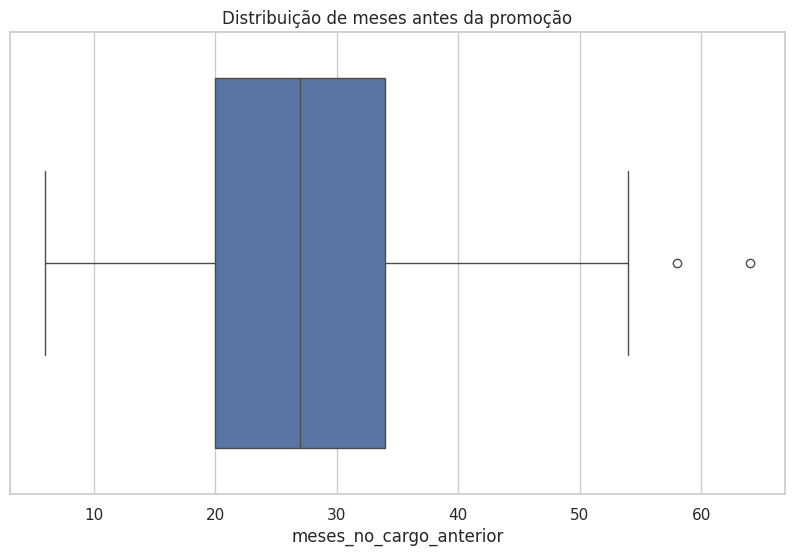

In [72]:
sns.boxplot(x=df_historico_promocoes["meses_no_cargo_anterior"])
plt.title("Distribuição de meses antes da promoção")
plt.show()
df_historico_promocoes = df_historico_promocoes[df_historico_promocoes["meses_no_cargo_anterior"] < 120]

`Hipótese de gênero`

In [66]:
tempo_promocao = df_historico_promocoes.groupby("sexo")["meses_no_cargo_anterior"].agg(
    media="mean",
    mediana="median",
    desvio="std",
    quantidade="count"
)
#inserir código para os gráficos
tempo_promocao

,media,mediana,desvio,quantidade
sexo,,,,
F,31.709220,31.0,10.495577,282
M,22.874214,23.0,8.072809,318


`Boxplot comparativo`